In [1]:
# %pip install corner

In [130]:
from lsst.rsp import get_tap_service
from lsst.rsp.service import get_siav2_service
from lsst.rsp.utils import get_pyvo_auth

import lsst.afw.display as afwDisplay
from lsst.afw.image import ExposureF
from lsst.afw.math import Warper, WarperConfig
from lsst.afw.fits import MemFileManager
import lsst.geom as geom

from pyvo.dal.adhoc import DatalinkResults, SodaQuery

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy import units as u
from astropy.table import Table
import corner

import time
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import random

service = get_tap_service("tap")
assert service is not None

sia_service = get_siav2_service("dp1")
assert sia_service is not None

afwDisplay.setDefaultBackend('matplotlib')

In [143]:
site = 'ecliptic'

def set_coords(site):
    match site:
        case 'ecdfs':
            return 53.16, -28.10
        case 'galactic':
            return 95.0, -25.0
        case 'ecliptic':
            return 37.98, 7.015

ra_cen, dec_cen = set_coords(site)

In [144]:
# query = """SELECT diaSourceId, band, visit, midpointMjdTai,
#         ra, dec, raErr, decErr, ra_dec_Cov, detector,
#         x, y, xErr, yErr, centroid_flag, psfChi2,
#         psfFlux, psfFluxErr, psfFlux_flag,
#         apFlux, apFluxErr, apFlux_flag, snr,
#         scienceFlux, scienceFluxErr, forced_PsfFlux_flag,
#         isDipole, dipoleChi2, dipoleFluxDiff, dipoleFluxDiffErr,
#         dipoleLength, dipoleMeanFlux, dipoleMeanFluxErr, dipoleNdata,
#         extendedness,
#         ixx, iyy, ixy, shape_flag,
#         ixxPSF, iyyPSF, ixyPSF, psfNdata,
#         pixelFlags, reliability, trailLength, trailFlux
#         FROM dp1.DiaSource
#         WHERE CONTAINS(POINT('ICRS', ra, dec),
#         CIRCLE('ICRS', {}, {}, 1.0)) = 1
#         ORDER BY diaSourceId ASC""".format(ra_cen, dec_cen)
# print(query)
# job = service.submit_job(query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'

# results = job.fetch_result().to_table()
# results.write(f'{site}.fits', format='fits', overwrite=True)
# print(len(results))

results = Table.read(f'{site}.fits')

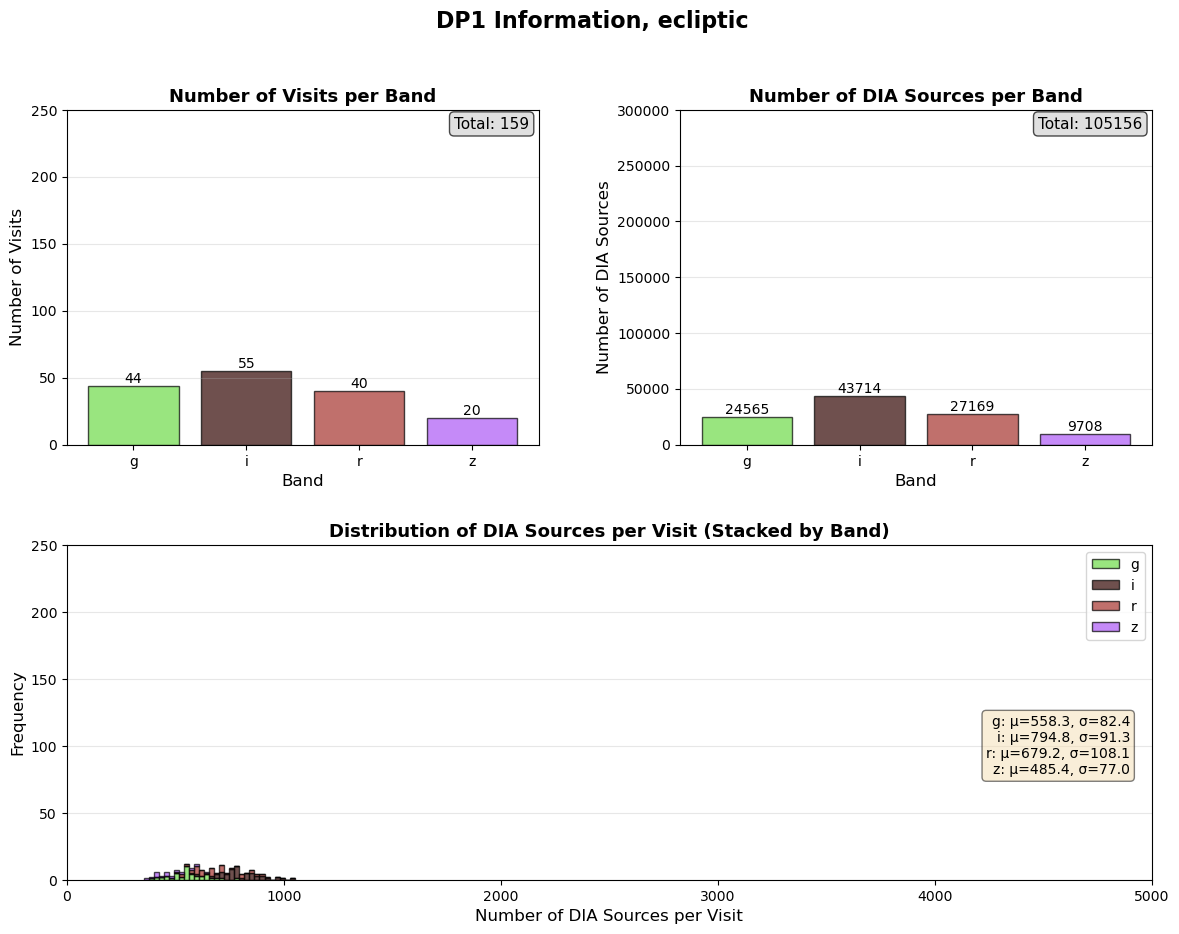

In [145]:
import numpy as np
import matplotlib.pyplot as plt

# Define color system with RGB values
band_colors = {
    'u': (19/255, 1/255, 224/255),
    'g': (110/255, 219/255, 73/255),
    'r': (166/255, 52/255, 46/255),
    'i': (50/255, 6/255, 3/255),
    'z': (173/255, 88/255, 246/255),
    'y': (112/255, 160/255, 177/255)
}

# 1. Count visits per band
unique_visits_per_band = {}
for band_name in np.unique(results['band']):
    band_mask = results['band'] == band_name
    unique_visits_per_band[band_name] = len(np.unique(results['visit'][band_mask]))

# 2. Count DIA sources per band
sources_per_band = {}
for band_name in np.unique(results['band']):
    band_mask = results['band'] == band_name
    sources_per_band[band_name] = np.sum(band_mask)

# 3. Count DIA sources per visit for each band
sources_per_visit_by_band = {}
for band_name in np.unique(results['band']):
    band_mask = results['band'] == band_name
    band_data = results[band_mask]
    
    unique_visits = np.unique(band_data['visit'])
    sources_per_visit = []
    
    for visit in unique_visits:
        visit_mask = band_data['visit'] == visit
        sources_per_visit.append(np.sum(visit_mask))
    
    sources_per_visit_by_band[band_name] = np.array(sources_per_visit)

# Calculate totals
total_visits = sum(unique_visits_per_band.values())
total_sources = sum(sources_per_band.values())

# Create visualizations
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

fig.suptitle(f'DP1 Information, {site}', fontsize=16, fontweight='bold')

bands = sorted(unique_visits_per_band.keys())
colors = [band_colors[b] for b in bands]

# Bar chart: Number of visits per band
ax1 = fig.add_subplot(gs[0, 0])
visits = [unique_visits_per_band[b] for b in bands]
bars1 = ax1.bar(bands, visits, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Band', fontsize=12)
ax1.set_ylabel('Number of Visits', fontsize=12)
ax1.set_title('Number of Visits per Band', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 250)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Add total visits text
ax1.text(0.98, 0.98, f'Total: {total_visits}', transform=ax1.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

# Bar chart: Number of DIA sources per band
ax2 = fig.add_subplot(gs[0, 1])
sources = [sources_per_band[b] for b in bands]
bars2 = ax2.bar(bands, sources, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Band', fontsize=12)
ax2.set_ylabel('Number of DIA Sources', fontsize=12)
ax2.set_title('Number of DIA Sources per Band', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 300000)
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Add total sources text
ax2.text(0.98, 0.98, f'Total: {total_sources}', transform=ax2.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

# Stacked histogram: DIA sources per visit
ax3 = fig.add_subplot(gs[1, :])
all_data = [sources_per_visit_by_band[b] for b in bands]

stats_text = []
for band in bands:
    data = sources_per_visit_by_band[band]
    mean_val = np.mean(data)
    std_val = np.std(data)
    stats_text.append(f'{band}: μ={mean_val:.1f}, σ={std_val:.1f}')

# Create histogram with appropriate bins
all_combined = np.concatenate(all_data)
bins = np.histogram_bin_edges(all_combined, bins=30)

n, bins, patches = ax3.hist(all_data, bins=bins, label=bands, 
                             color=colors, alpha=0.7, 
                             edgecolor='black', stacked=True)

ax3.set_xlabel('Number of DIA Sources per Visit', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of DIA Sources per Visit (Stacked by Band)', 
              fontsize=13, fontweight='bold')
ax3.set_xlim(0, 5000)
ax3.set_ylim(0, 250)
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

stats_str = '\n'.join(stats_text)
ax3.text(0.98, 0.4, stats_str, transform=ax3.transAxes,
        fontsize=10, verticalalignment='center', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig(f'a_dia_source_analysis_{site}.png', dpi=300, bbox_inches='tight')
plt.show()

In [127]:
filtered = results

sel_snr = filtered['snr'] > 20
filtered = filtered[sel_snr]

# sel_not_dipole = ~filtered['isDipole']
# filtered = filtered[sel_not_dipole]

sel_no_flag = ~filtered['apFlux_flag']
sel_no_flag &= ~filtered['psfFlux_flag']
filtered = filtered[sel_no_flag]

# ap_psf = np.abs(filtered['psfFlux'] < np.abs(filtered['apFlux']))
# filtered = filtered[ap_psf]

same_sign = ((filtered['psfFlux'] > 0) & (filtered['apFlux'] > 0) & (filtered['scienceFlux'] > 0)) | \
            ((filtered['psfFlux'] < 0) & (filtered['apFlux'] < 0) & (filtered['scienceFlux'] < 0))
filtered = filtered[same_sign]

reliability = filtered['reliability'] > 0.5
filtered = filtered[reliability]

# columns = ['psfFlux', 'apFlux', 'scienceFlux', 'psfChi2', 'extendedness', 
#            'ixx', 'iyy', 'ixy', 'ixxPSF', 'iyyPSF', 'ixyPSF']
# mask = np.ones(len(filtered), dtype=bool)
# for col in columns:
#     mask &= np.isfinite(filtered[col])
# filtered = filtered[mask]
print(len(filtered))

2794


In [128]:
filtered['flux_ext'] = filtered['apFlux'] / filtered['psfFlux']
ixx_adj = filtered['ixx'] - filtered['ixxPSF']
iyy_adj = filtered['iyy'] - filtered['iyyPSF']
ixy_adj = filtered['ixy'] - filtered['ixyPSF']
filtered['elip_simp_ext'] = np.sqrt((ixx_adj-iyy_adj)**2 + 4*(ixy_adj)**2) / (ixx_adj + iyy_adj)
filtered['elip_ext'] = np.sqrt((ixx_adj - iyy_adj)**2 + 4 * ixy_adj**2) / (ixx_adj + iyy_adj + 2 * np.sqrt(np.maximum(ixx_adj * iyy_adj - ixy_adj**2, 0)))
filtered['i_ext'] = (filtered['ixx']+filtered['iyy']) / (filtered['ixxPSF']+filtered['iyyPSF'])

results_s = filtered

ext_filter = (results_s['flux_ext'] > 1.259) & (results_s['i_ext'] > 1.5) & (results_s['elip_ext'] > 0.4)
results_s = results_s[ext_filter]
print(len(results_s))

12


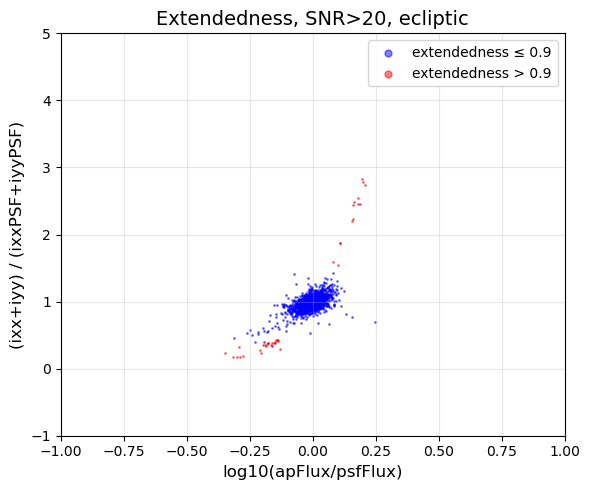

In [112]:
fig, ax = plt.subplots(figsize=(6, 5))

y_data = filtered['i_ext']
x_data = np.log10(filtered['flux_ext'])

extended_mask = filtered['extendedness'] > 0.9
not_extended_mask = ~extended_mask

ax.scatter(x_data[not_extended_mask], y_data[not_extended_mask], 
           alpha=0.5, s=1, c='blue', label='extendedness ≤ 0.9')

ax.scatter(x_data[extended_mask], y_data[extended_mask], 
           alpha=0.5, s=1, c='red', label='extendedness > 0.9')

ax.set_xlabel('log10(apFlux/psfFlux)', fontsize=12)
ax.set_ylabel('(ixx+iyy) / (ixxPSF+iyyPSF)', fontsize=12)
ax.set_title(f'Extendedness, SNR>20, {site}', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(markerscale=5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 5)

plt.tight_layout()
plt.savefig(f'a_ext_{site}.png', dpi=300)
plt.show()

In [113]:
# fig, ax = plt.subplots(figsize=(7, 5))
# y_data = filtered['i_ext']
# x_data = np.log10(filtered['flux_ext'])

# # Assuming you have an SNR column - adjust the column name as needed
# snr_data = filtered['reliability']  # or whatever your SNR column is called

# scatter = ax.scatter(x_data, y_data, 
#                      alpha=0.5, s=1, c=snr_data, 
#                      cmap='viridis_r', label=None, vmin=0, vmax=1)

# ax.set_xlabel('log10(apFlux/psfFlux)', fontsize=12)
# ax.set_ylabel('(ixx+iyy) / (ixxPSF+iyyPSF)', fontsize=12)
# ax.set_title(f'Reliability, {site}', fontsize=14)
# ax.grid(True, alpha=0.3)
# ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 5)

# # Add colorbar
# cbar = plt.colorbar(scatter, ax=ax, label='reliability')

# plt.tight_layout()
# plt.savefig(f'a_reliability_{site}.png', dpi=300)
# plt.show()

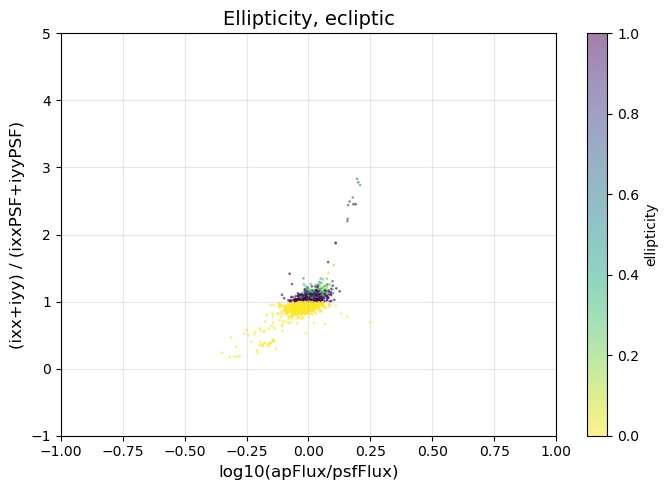

In [114]:
fig, ax = plt.subplots(figsize=(7, 5))
y_data = filtered['i_ext']
x_data = np.log10(filtered['flux_ext'])

# Assuming you have an SNR column - adjust the column name as needed
snr_data = filtered['elip_ext']  # or whatever your SNR column is called

scatter = ax.scatter(x_data, y_data, 
                     alpha=0.5, s=1, c=snr_data, 
                     cmap='viridis_r', label=None, vmin=0, vmax=1)

ax.set_xlabel('log10(apFlux/psfFlux)', fontsize=12)
ax.set_ylabel('(ixx+iyy) / (ixxPSF+iyyPSF)', fontsize=12)
ax.set_title(f'Ellipticity, {site}', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 5)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='ellipticity')

plt.tight_layout()
plt.savefig(f'a_ellipticity_{site}.png', dpi=300)
plt.show()

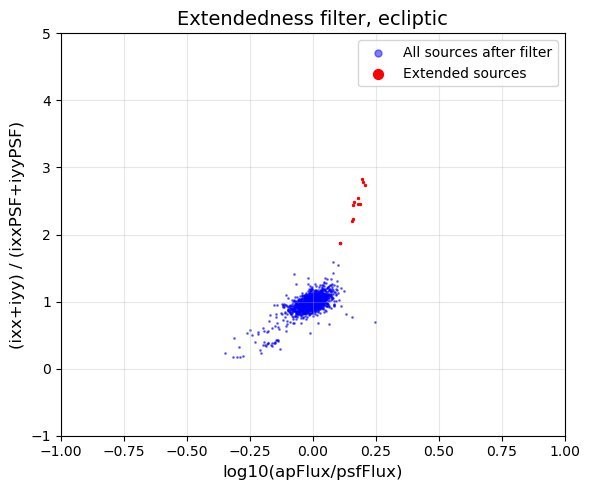

In [115]:
fig, ax = plt.subplots(figsize=(6, 5))

y_data1 = filtered['i_ext']
x_data1 = np.log10(filtered['flux_ext'])

y_data2 = results_s['i_ext']
x_data2 = np.log10(results_s['flux_ext'])

ax.scatter(x_data1, y_data1, 
           alpha=0.5, s=1, c='blue', label='All sources after filter')

ax.scatter(x_data2, y_data2, 
           alpha=1, s=2, c='red', label='Extended sources')

ax.set_xlabel('log10(apFlux/psfFlux)', fontsize=12)
ax.set_ylabel('(ixx+iyy) / (ixxPSF+iyyPSF)', fontsize=12)
ax.set_title(f'Extendedness filter, {site}', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(markerscale=5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 5)

plt.tight_layout()
plt.savefig(f'a_filter_{site}.png', dpi=300)
plt.show()

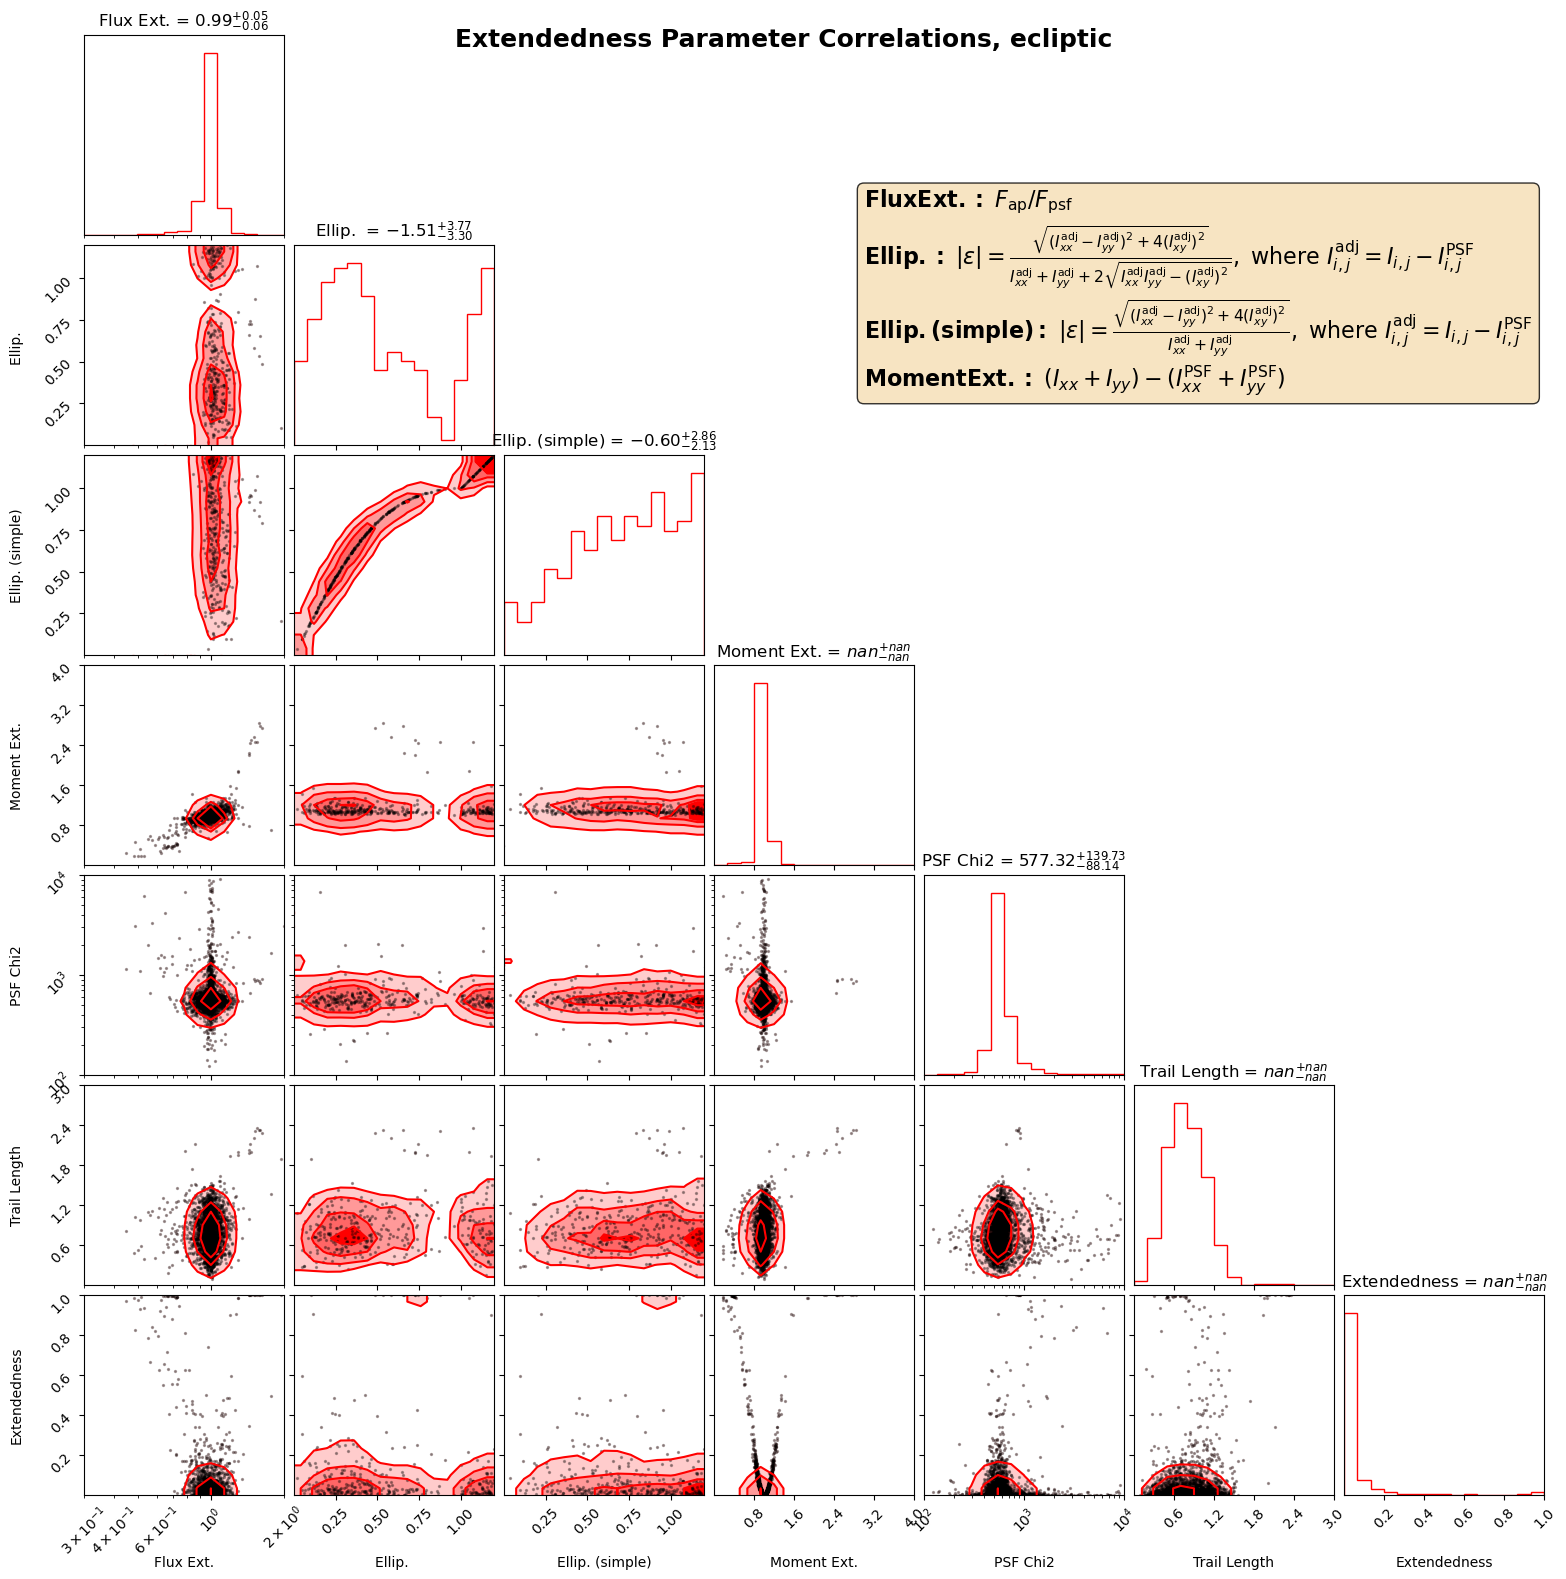

In [116]:
# Corner plot for flux_ext, elip_ext, i_ext, psfChi2, and trailLength
columns_corner = ['flux_ext', 'elip_ext', 'elip_simp_ext', 'i_ext', 'psfChi2', 'trailLength', 'extendedness']

# Define axes scale: log for flux_ext, elip_ext, and psfChi2; linear for i_ext and trailLength
axes_scale = ['log', 'linear', 'linear', 'linear', 'log', 'linear', 'linear']

# Define ranges for each variable
ranges = [(0.3, 2.0), (0, 1.2), (0, 1.2), (0, 4), (100, 10000), (0, 3), (0, 1)]

# Sample data to speed up plotting
sample_size = min(10000, len(filtered))
sample_indices = np.random.choice(len(filtered), size=sample_size, replace=False)
sample_data = filtered[sample_indices]

# Prepare data array for corner plot
data_array = [sample_data[col] for col in columns_corner]

# Simple labels for axes
labels = [
    'Flux Ext.',
    'Ellip. ',
    'Ellip. (simple)',
    'Moment Ext.',
    'PSF Chi2',
    'Trail Length',
    'Extendedness'
]

# Create corner plot
fig = corner.corner(np.array(data_array).T, 
                    labels=labels,
                    axes_scale=axes_scale,
                    range=ranges,
                    fill_contours=True, 
                    smooth=0.7, 
                    show_titles=True, 
                    color='red',
                    plot_datapoints=True,
                    plot_contours=True,
                    plot_density=True,
                    bins=15)

axes = np.array(fig.axes).reshape((len(columns_corner), len(columns_corner)))
for i in range(len(columns_corner)):
    for j in range(i):
        ax = axes[i, j]
        ax.scatter(data_array[j], data_array[i], s=2, alpha=0.3, color='black', rasterized=True)

fig.suptitle(f'Extendedness Parameter Correlations, {site}', fontsize=18, fontweight='bold', y=0.98)

# Add formulas in top right corner (only for first 3 variables)
formula_text = (
    r'$\mathbf{FluxExt.:}$ $F_{\rm ap}/F_{\rm psf}$' + '\n'
    r'$\mathbf{Ellip.:}$ $|\epsilon| = \frac{\sqrt{(I_{xx}^{\text{adj}} - I_{yy}^{\text{adj}})^2 + 4(I_{xy}^{\text{adj}})^2}}{I_{xx}^{\text{adj}} + I_{yy}^{\text{adj}} + 2\sqrt{I_{xx}^{\text{adj}}I_{yy}^{\text{adj}} - (I_{xy}^{\text{adj}})^2}}, \text{ where } I_{i,j}^{\text{adj}} = I_{i,j} - I_{i,j}^{\text{PSF}}$' + '\n'
    r'$\mathbf{Ellip. (simple):}$ $|\epsilon| = \frac{\sqrt{(I_{xx}^{\text{adj}} - I_{yy}^{\text{adj}})^2 + 4(I_{xy}^{\text{adj}})^2}}{I_{xx}^{\text{adj}} + I_{yy}^{\text{adj}}}, \text{ where } I_{i,j}^{\text{adj}} = I_{i,j} - I_{i,j}^{\text{PSF}}$' + '\n'    
    r'$\mathbf{Moment Ext.:}$ $(I_{xx}+I_{yy}) - (I_{xx}^{\rm PSF}+I_{yy}^{\rm PSF})$'
)

fig.text(0.55, 0.88, formula_text, transform=fig.transFigure, 
         fontsize=16, verticalalignment='top', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.8))

fig.savefig(f'a_corner_{site}.png', dpi=300)
plt.show()

In [117]:
# results_s = results_s[(results_s['flux_ext']<0.4) & (results_s['flux_ext'] > 0.2) & (results_s['i_ext']<2) & (results_s['i_ext']>1)]
results_s = results_s[(results_s['extendedness']>0.9)]
len(results_s)

12

In [118]:
# results_s = results_s[(results_s['flux_ext']<0.4) & (results_s['flux_ext'] > 0.2) & (results_s['i_ext']<2) & (results_s['i_ext']>1)]
results_s = results_s[results_s['visit'] == 2024111700129]


Starting gallery creation at 08:34:34
Layout: 3 columns x 4 rows = 12 images

[08:34:47] ✓ 1/12: visit=2024112600113, diaSourceId=600399334629965840, time=12.8s
[08:34:48] ✓ 2/12: visit=2024112600113, diaSourceId=600399334632063035, time=13.6s
[08:35:00] ✓ 3/12: visit=2024112600127, diaSourceId=600399336510062630, time=12.9s
[08:35:01] ✓ 4/12: visit=2024112600109, diaSourceId=600399334094143531, time=12.9s
[08:35:13] ✓ 5/12: visit=2024112600113, diaSourceId=600399334632063009, time=12.8s
[08:35:14] ✓ 6/12: visit=2024112600113, diaSourceId=600399334632063041, time=12.8s
[08:35:25] ✓ 7/12: visit=2024112600113, diaSourceId=600399334631014415, time=11.8s
[08:35:26] ✓ 8/12: visit=2024112600105, diaSourceId=600399333557272590, time=12.4s
[08:35:36] ✓ 9/12: visit=2024112600113, diaSourceId=600399334632062987, time=9.9s
[08:35:37] ✓ 10/12: visit=2024112600113, diaSourceId=600399334632063050, time=12.0s
[08:35:48] ✓ 11/12: visit=2024112600113, diaSourceId=600399334630490179, time=11.6s
[08:35:

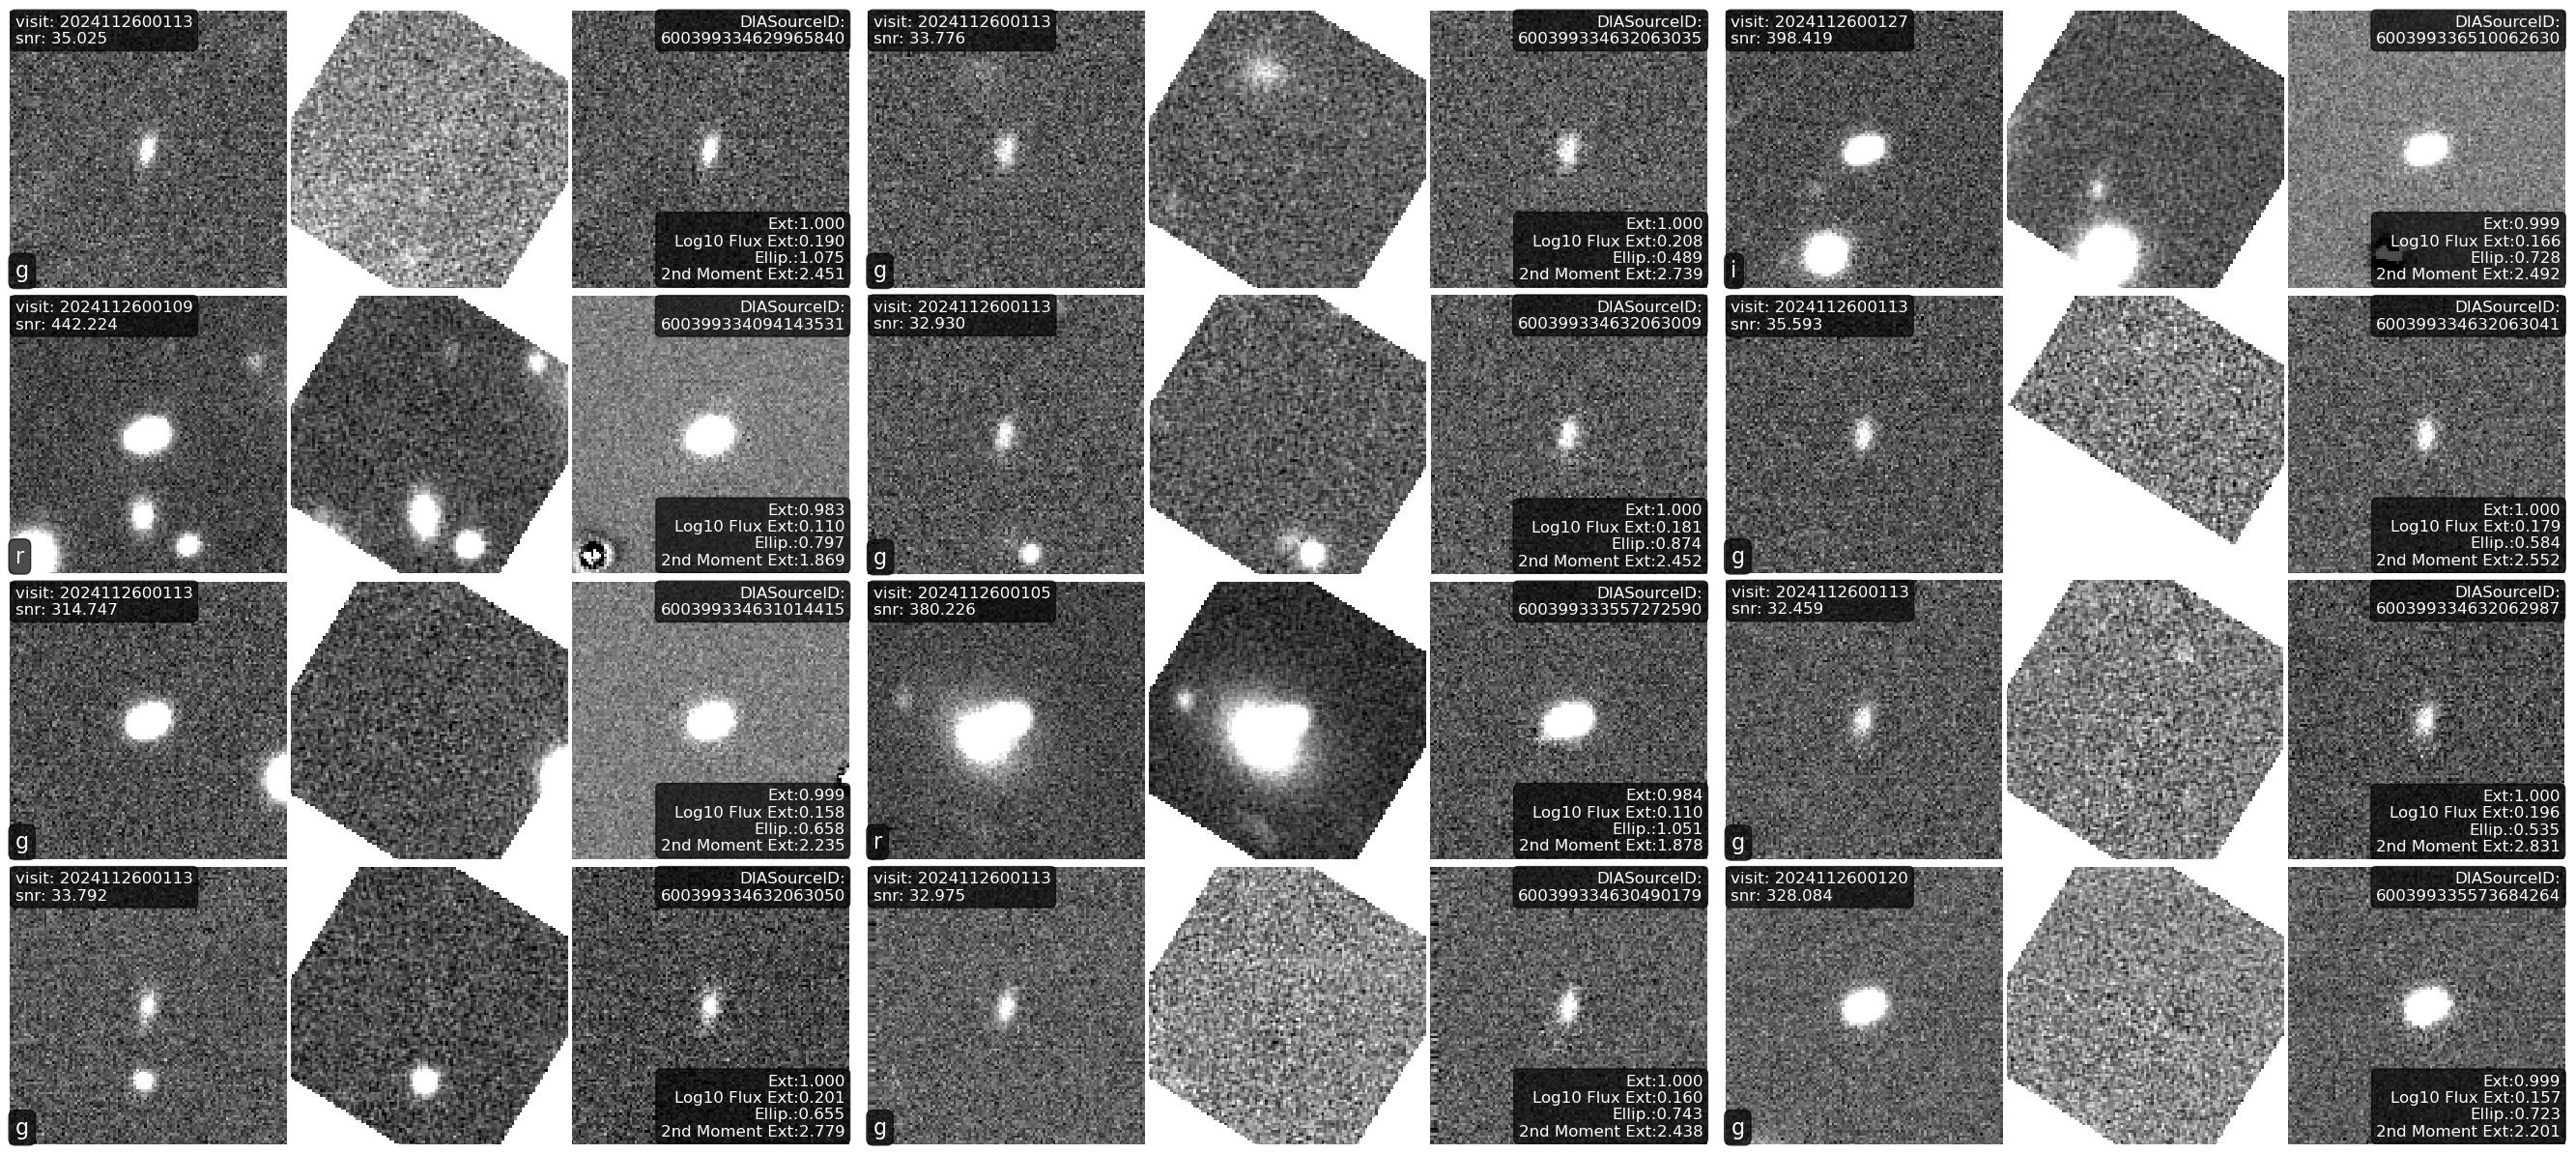

In [129]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
LAYOUT_COLS = 3  # Number of columns
LAYOUT_ROWS = 4  # Number of rows
# Total images will be LAYOUT_COLS * LAYOUT_ROWS
# Examples: 3x7=21, 2x10=20, 2x2=4, 1x5=5
# ==============================================================================

def get_cutout_with_retry(dl_result, spherePoint, session, fov, max_retries=3):
    """Get a cutout with exponential backoff retry logic."""
    sq = SodaQuery.from_resource(dl_result,
                                 dl_result.get_adhocservice_by_id("cutout-sync-exposure"),
                                 session=session)
    sphereRadius = fov * u.deg
    sq.circle = (spherePoint.getRa().asDegrees() * u.deg,
                 spherePoint.getDec().asDegrees() * u.deg,
                 sphereRadius)
    
    for attempt in range(max_retries):
        try:
            cutout_bytes = sq.execute_stream().read()
            sq.raise_if_error()
            mem = MemFileManager(len(cutout_bytes))
            mem.setData(cutout_bytes, len(cutout_bytes))
            return ExposureF(mem)
        except Exception as e:
            if '429' in str(e) and attempt < max_retries - 1:
                # Rate limit hit - wait with exponential backoff
                wait_time = (2 ** attempt) + random.uniform(0, 1)
                time.sleep(wait_time)
            else:
                raise

def fetch_images_for_row(row, sia_service, get_pyvo_auth, fov=0.003):
    """Fetch all images for a single row with rate limiting."""
    try:
        row_start = time.time()
        
        ra = row['ra']
        dec = row['dec']
        visit = row['visit']
        band = row['band']
        diaSourceId = row['diaSourceId']  # Get diaSourceId from row
        snr = row['snr']
        extendedness = row['extendedness']
        flux_ext = row['flux_ext']
        elip_ext = row['elip_ext']
        i_ext = row['i_ext']
        
        spherePoint = geom.SpherePoint(ra*geom.degrees, dec*geom.degrees)
        circle = (ra, dec, 0.0001)
        
        # SIA searches
        t0 = time.time()
        lvl2_table = sia_service.search(pos=circle, calib_level=2).to_table()
        sel = lvl2_table['dataproduct_subtype'] == 'lsst.visit_image'
        sel &= lvl2_table['lsst_visit'] == visit
        sci_table = lvl2_table[sel]
        
        if len(sci_table) == 0:
            return None, f"No science images found"
        
        lvl3_table = sia_service.search(pos=circle, calib_level=3).to_table()
        search_time = time.time() - t0
        
        # Template
        sel = lvl3_table['dataproduct_subtype'] == 'lsst.template_coadd'
        sel &= lvl3_table['lsst_band'] == band
        ref_table = lvl3_table[sel]
        
        if len(ref_table) == 0:
            return None, f"No template images found"
        
        # Difference
        sel = lvl3_table['dataproduct_subtype'] == 'lsst.difference_image'
        sel &= lvl3_table['lsst_visit'] == visit
        diff_table = lvl3_table[sel]
        
        if len(diff_table) == 0:
            return None, f"No difference images found"
        
        # Get datalink results
        t0 = time.time()
        dl_result_sci = DatalinkResults.from_result_url(sci_table['access_url'][0], session=get_pyvo_auth())
        dl_result_ref = DatalinkResults.from_result_url(ref_table['access_url'][0], session=get_pyvo_auth())
        dl_result_diff = DatalinkResults.from_result_url(diff_table['access_url'][0], session=get_pyvo_auth())
        datalink_time = time.time() - t0
        
        # Download cutouts sequentially with small delays to avoid rate limiting
        # (parallel downloading within each row was causing 429 errors)
        t0 = time.time()
        sci = get_cutout_with_retry(dl_result_sci, spherePoint, get_pyvo_auth(), fov)
        time.sleep(0.3)  # Small delay between cutouts
        ref = get_cutout_with_retry(dl_result_ref, spherePoint, get_pyvo_auth(), fov)
        time.sleep(0.3)
        diff = get_cutout_with_retry(dl_result_diff, spherePoint, get_pyvo_auth(), fov)
        download_time = time.time() - t0
        
        # Warp reference
        t0 = time.time()
        warper_config = WarperConfig()
        warper = Warper.fromConfig(warper_config)
        sci_wcs = sci.getWcs()
        sci_bbox = sci.getBBox()
        warped_ref = warper.warpExposure(sci_wcs, ref, destBBox=sci_bbox)
        warp_time = time.time() - t0
        
        total_time = time.time() - row_start
        
        return {
            'success': True,
            'visit': visit,
            'band': band,
            'diaSourceId': diaSourceId,
            'ra': ra,
            'dec': dec,
            'sci': sci,
            'snr': snr,
            'extendedness': extendedness,
            'flux_ext': flux_ext,
            'elip_ext': elip_ext,
            'i_ext': i_ext,
            'warped_ref': warped_ref,
            'diff': diff,
            'search_time': search_time,
            'datalink_time': datalink_time,
            'download_time': download_time,
            'warp_time': warp_time,
            'total_time': total_time
        }, None
        
    except Exception as e:
        return None, str(e)

# Assuming you have results_s as your dataframe/table
# Sample based on layout configuration
n_images = LAYOUT_COLS * LAYOUT_ROWS
sample_indices = np.random.choice(len(results_s), size=min(n_images, len(results_s)), replace=False)
sampled_rows = [results_s[i] for i in sample_indices]

print(f"\n{'='*60}")
print(f"Starting gallery creation at {datetime.now().strftime('%H:%M:%S')}")
print(f"Layout: {LAYOUT_COLS} columns x {LAYOUT_ROWS} rows = {n_images} images")
print(f"{'='*60}\n")
start_time = time.time()

# Process rows with limited parallelism (2 workers = 2 rows at once)
# This should be fast enough while staying under rate limits
results = []
with ThreadPoolExecutor(max_workers=2) as executor:
    futures = {executor.submit(fetch_images_for_row, row, sia_service, get_pyvo_auth): idx 
               for idx, row in enumerate(sampled_rows)}
    
    for future in as_completed(futures):
        idx = futures[future]
        result, error = future.result()
        
        if result:
            print(f"[{datetime.now().strftime('%H:%M:%S')}] ✓ {len(results)+1}/{n_images}: visit={result['visit']}, diaSourceId={result['diaSourceId']}, time={result['total_time']:.1f}s")
            results.append(result)
        else:
            print(f"[{datetime.now().strftime('%H:%M:%S')}] ✗ Failed: {error}")
        
        if len(results) >= n_images:
            break

fetch_time = time.time() - start_time
print(f"\nAll images fetched in {fetch_time:.1f}s ({fetch_time/60:.1f} min)")
print(f"Average per image set: {fetch_time/len(results):.1f}s\n")

# Now plot all results
print("Creating plots...")
plot_start = time.time()

# Create figure with tight layout and no padding
fig = plt.figure(figsize=(LAYOUT_COLS * 9, LAYOUT_ROWS * 3))  # Wider to fit 3 square images per row
gs = GridSpec(LAYOUT_ROWS, LAYOUT_COLS, figure=fig, 
              hspace=0.02, wspace=0.02,  # Minimal space between cells
              left=0.01, right=0.99, top=0.99, bottom=0.01)  # Tight margins

for idx, result in enumerate(results[:n_images]):
    gallery_row = idx // LAYOUT_COLS
    gallery_col = idx % LAYOUT_COLS
    
    # Very tight spacing within each cell - 3 images side by side
    gs_sub = gs[gallery_row, gallery_col].subgridspec(1, 3, wspace=0.01)
    
    ax1 = fig.add_subplot(gs_sub[0, 0])
    ax2 = fig.add_subplot(gs_sub[0, 1])
    ax3 = fig.add_subplot(gs_sub[0, 2])
    
    # Display images without colorbars, preserving aspect ratio
    for ax, img in [(ax1, result['sci']), (ax2, result['warped_ref']), (ax3, result['diff'])]:
        # Use imshow directly to have full control over display
        from matplotlib.colors import Normalize
        from astropy.visualization import ZScaleInterval
        
        # Apply zscale
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(img.image.array)
        
        ax.imshow(img.image.array, cmap='gray', origin='lower', 
                  vmin=vmin, vmax=vmax, aspect='equal', interpolation='nearest')
        ax.set_axis_off()
        # Remove all padding around the image
        ax.set_position(ax.get_position())
        ax.margins(0, 0)
        ax.set_xlim(0, img.image.array.shape[1])
        ax.set_ylim(0, img.image.array.shape[0])
    
    # Add labels
    # Visit number on first image (top)
    ax1.text(0.02, 0.98, f'visit: {result["visit"]}\nsnr: {(result["snr"]):.3f}', 
             transform=ax1.transAxes, ha='left', va='top',
             fontsize=12, color='white',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # Band on first image (bottom left)
    ax1.text(0.02, 0.02, f'{result["band"]}', 
             transform=ax1.transAxes, ha='left', va='bottom',
             fontsize=16, color='white',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # DIASourceID on difference image (third image)
    ax3.text(0.98, 0.98, f'DIASourceID:\n{result["diaSourceId"]}', 
             transform=ax3.transAxes, ha='right', va='top',
             fontsize=12, color='white',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

    ax3.text(0.98, 0.02, f'Ext:{result["extendedness"]:.3f}\nLog10 Flux Ext:{np.log10(result["flux_ext"]):.3f}\nEllip.:{(result["elip_ext"]):.3f}\n2nd Moment Ext:{(result["i_ext"]):.3f}', 
             transform=ax3.transAxes, ha='right', va='bottom',
             fontsize=12, color='white',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

plot_time = time.time() - plot_start
print(f"Plotting complete in {plot_time:.1f}s")

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"Complete at {datetime.now().strftime('%H:%M:%S')}")
print(f"Total time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"Created {len(results)} image sets")
print(f"{'='*60}\n")

# plt.tight_layout(pad=0)
plt.savefig(f'a_gallery_{site}.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
print("Saved to: image_gallery.png")
plt.show()

In [80]:
results_s

diaSourceId,band,visit,midpointMjdTai,ra,dec,raErr,decErr,ra_dec_Cov,x,y,xErr,yErr,centroid_flag,psfChi2,psfFlux,psfFluxErr,psfFlux_flag,apFlux,apFluxErr,apFlux_flag,snr,scienceFlux,scienceFluxErr,forced_PsfFlux_flag,isDipole,dipoleChi2,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleMeanFlux,dipoleMeanFluxErr,dipoleNdata,extendedness,ixx,iyy,ixy,shape_flag,ixxPSF,iyyPSF,ixyPSF,psfNdata,pixelFlags,reliability,trailLength,trailFlux,flux_ext,elip_ext,i_ext
,,,d,deg,deg,deg,deg,deg2,pix,pix,pix,pix,,,nJy,nJy,,nJy,nJy,,,nJy,nJy,,,,nJy,nJy,pix,ct,ct,,,arcsec2,arcsec2,arcsec2,,arcsec2,arcsec2,arcsec2,pix,,,pix,nJy,nJy,arcsec2,arcsec2
int64,bytes1,int64,float64,float64,float64,float32,float32,float32,float64,float64,float32,float32,bool,float32,float32,float32,bool,float32,float32,bool,float64,float32,float32,bool,bool,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,bool,float64,float64,float64,int32,bool,float32,float64,float32,float32,float64,float64
600320195834150959,g,2024110800307,60623.31157469336,53.48183750876727,-28.122667964275493,3.04757e-06,5.10025e-06,2.95284e-12,3097.3806292593167,2363.7953095468224,0.0929576,0.060071,False,2905.6,15401.9,161.358,False,22713.9,297.739,False,94.1485595703125,15420.4,162.044,False,False,--,--,--,--,--,--,0,0.9999996427588553,0.8097999803751478,0.32929984921707023,-0.17196025673036472,False,0.2165100630164085,0.20971632273185248,-0.02207843687829001,625,False,0.958806,2.3451553262795906,20044.8,1.4747466,0.7863743547559079,0.7128734438439569
600320195834150967,g,2024110800307,60623.31157469336,53.484924711915475,-28.19481011123648,3.32622e-06,5.8455e-06,4.17328e-12,1844.3248221746842,2697.2889700907594,0.106624,0.0651843,False,1314.4,12145.1,158.895,False,15503.3,300.166,False,75.00894927978516,12214.6,159.822,False,False,--,--,--,--,--,--,0,0.9906630361000496,0.6120120117918036,0.24118812334653703,-0.1348115139866107,False,0.23748566298241047,0.20709458420451043,-0.02197155291162726,625,False,0.961298,2.057989136216392,14457.9,1.2765065,0.9995678305355973,0.4086198879514198
600320195834675238,g,2024110800307,60623.31157469336,53.470066918849305,-27.849616886778414,3.87917e-06,5.93287e-06,3.36479e-12,3613.7586433034357,1098.5325283443724,0.107926,0.07705,False,2133.48,10484.7,140.369,False,16340.9,289.808,False,73.87699127197266,10805.1,143.478,False,False,--,--,--,--,--,--,0,0.9999974871124812,0.7158487798523595,0.3221460842052416,-0.15674280100154955,False,0.17866909530702318,0.2183384094234784,-0.011451694446987168,625,False,0.941092,2.1793870242440145,13880.4,1.5585473,0.8140178680229393,0.6409873593270995
600320195834675243,g,2024110800307,60623.31157469336,53.4731802983925,-27.9212367243448,3.85999e-06,6.19871e-06,4.07173e-12,2369.117490378439,1430.6390637629486,0.112915,0.0763227,False,1742.85,10962.7,150.323,False,16385.4,300.212,False,72.10518646240234,11131.4,154.348,False,False,--,--,--,--,--,--,0,0.9999578309764641,0.6860597847669935,0.29311344161569286,-0.09769752071833866,False,0.18649198392732344,0.21964995230412743,-0.014698884665911575,625,False,0.950806,2.0508451173059274,13528.5,1.49465,0.7980303821096489,0.5730312901512354
600320195835199527,g,2024110800307,60623.31157469336,53.46784941456225,-27.798249278212083,1.05029e-05,1.51132e-05,1.83988e-11,281.9404417761822,860.1229645867079,0.274371,0.20977,False,796.967,3820.85,126.276,False,5592.3,286.119,False,30.23172950744629,3767.4,130.2,False,False,--,--,--,--,--,--,0,0.9996794217403839,0.6094593702370948,0.29510968445724683,-0.11310206643852463,False,0.17405683953836987,0.22369741696433465,-0.008503643646740333,625,False,0.917254,1.9348513388895956,4740.4,1.4636271,0.8283579134828866,0.5068147981916371
600359754359373836,r,2024111700129,60632.07398926506,53.45936487749283,-27.949773740759877,1.36673e-05,2.09229e-05,8.19745e-11,3856.803095216962,392.20866157801004,0.255831,0.391089,False,1340.26,5807.13,171.176,False,11763.1,461.286,False,33.80146026611328,5945.99,175.314,False,

In [73]:
filtered

diaSourceId,band,visit,midpointMjdTai,ra,dec,raErr,decErr,ra_dec_Cov,x,y,xErr,yErr,centroid_flag,psfChi2,psfFlux,psfFluxErr,psfFlux_flag,apFlux,apFluxErr,apFlux_flag,snr,scienceFlux,scienceFluxErr,forced_PsfFlux_flag,isDipole,dipoleChi2,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleMeanFlux,dipoleMeanFluxErr,dipoleNdata,extendedness,ixx,iyy,ixy,shape_flag,ixxPSF,iyyPSF,ixyPSF,psfNdata,pixelFlags,reliability,trailLength,trailFlux,flux_ext,elip_ext,i_ext
,,,d,deg,deg,deg,deg,deg2,pix,pix,pix,pix,,,nJy,nJy,,nJy,nJy,,,nJy,nJy,,,,nJy,nJy,pix,ct,ct,,,arcsec2,arcsec2,arcsec2,,arcsec2,arcsec2,arcsec2,pix,,,pix,nJy,nJy,arcsec2,arcsec2
int64,bytes1,int64,float64,float64,float64,float32,float32,float32,float64,float64,float32,float32,bool,float32,float32,float32,bool,float32,float32,bool,float64,float32,float32,bool,bool,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,bool,float64,float64,float64,int32,bool,float32,float64,float32,float32,float64,float64
600320187513700376,i,2024110800245,60623.258520653835,53.58351270836558,-27.812040461603246,1.4558e-06,6.4469e-07,-4.8005e-13,2252.2786943655665,995.3316261567443,0.00973753,0.0302381,False,40622.6,72863.4,339.194,False,58840.3,661.82,False,209.9461212158203,74226.4,349.422,False,False,--,--,--,--,--,--,0,0.1328025518745879,0.025383325537677432,0.29792804584993204,-0.021092420570288505,False,0.11651914338668745,0.15143334008809212,0.010103683556321836,625,False,0.99999,1.5061053652217995,84433.9,0.8075426,4.438038322396945,0.05535888791282989
600320187913207878,i,2024110800248,60623.26073882533,52.97730748249818,-27.7057507236732,1.73075e-06,1.4261e-06,-3.85258e-13,3669.0312288355626,2271.1199462747463,0.0249693,0.0355818,False,4216.19,16772.7,289.595,False,9101.03,628.066,False,56.12471389770508,17153.3,296.758,False,False,--,--,--,--,--,--,0,--,--,--,--,True,0.10522187778828175,0.14421873654882317,-0.004162997277362094,625,False,0.929433,--,--,0.54260975,--,--
600320187916353538,i,2024110800248,60623.26073882533,53.316833872782794,-27.952447428923108,4.09112e-06,6.65696e-06,4.81036e-12,548.8064206470283,64.53412997687931,0.121314,0.0808291,False,1115.72,4374.8,198.899,False,3509.74,590.243,False,21.384490966796875,4518.72,202.056,False,False,--,--,--,--,--,--,0,--,--,--,--,True,0.0971109773369686,0.13487764241893882,-0.00687445493096207,625,False,0.986968,--,--,0.802263,--,--
600320188046901276,i,2024110800249,60623.26130679388,52.90608412791057,-28.055462132395213,1.06313e-05,4.46719e-06,-2.70211e-11,2715.5306219718645,1534.817230669107,0.0644883,0.221701,False,1477.8,6790.04,218.706,False,3752.75,586.728,False,29.14749526977539,6829.23,220.922,False,False,--,--,--,--,--,--,0,0.06945871066741471,0.020283494533489124,0.20332600824547126,-0.0010790918658206495,False,0.11104920847935744,0.15150255527268922,0.005531138148623691,625,False,0.953704,1.2342472250872125,6746.7,0.55268455,-3.677257905722299,-0.03894226097308626
600320188315336799,r,2024110800251,60623.2626942534,52.86167846661847,-28.055860973520023,5.11433e-06,4.04056e-06,-3.7028e-12,1241.5953914341158,3945.40450038704,0.0704471,0.105645,False,879.75,2929.3,133.608,False,2116.69,355.964,False,20.17840576171875,2994.15,135.382,False,False,--,--,--,--,--,--,0,0.7863745325287196,0.022094974747187145,0.05880465245589389,-0.005465660363587815,False,0.11405834673049939,0.14646232521136462,0.000649819203433213,625,False,0.907734,0.6026701734239086,2551.21,0.7225924,-0.07218922375671707,-0.179621044738783
600320188450603075,i,2024110800252,60623.263519415406,52.99442533292299,-28.317062444644474,3.34187e-06,2.60335e-06,-1.61426e-12,1323.6943855104478,2823.8511302819866,0.0453145,0.0692218,False,1800.56,8816.76,252.262,False,5626.11,610.134,False,33.98527145385742,23696.7,253.529,False,False,--,--,--,--,--,--,0,0.16768474352312324,0.055824687976275315,0.1453711556424491,-0.08045861746264565,False,0.1379624655915237,0.12553011866485778,-0.012185539795093566,625,False,0.886324,1.218022674564497